In [23]:
#匯入工具
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import mplfinance as mpf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor

In [24]:
#讀取資料 
uber_stock = pd.read_csv("./uber_stock_data.csv")

In [25]:
print(uber_stock)

            Date  Adj Close      Close       High        Low       Open  \
0     2019-05-10  41.570000  41.570000  45.000000  41.060001  42.000000   
1     2019-05-13  37.099998  37.099998  39.240002  36.080002  38.790001   
2     2019-05-14  39.959999  39.959999  39.959999  36.849998  38.310001   
3     2019-05-15  41.290001  41.290001  41.880001  38.950001  39.369999   
4     2019-05-16  43.000000  43.000000  44.060001  41.250000  41.480000   
...          ...        ...        ...        ...        ...        ...   
1439  2025-01-30  66.589996  66.589996  67.222000  63.419998  63.419998   
1440  2025-01-31  66.849998  66.849998  67.870003  66.333000  67.089996   
1441  2025-02-03  67.290001  67.290001  68.849998  65.178001  65.300003   
1442  2025-02-04  69.750000  69.750000  70.190002  67.690002  67.690002   
1443  2025-02-05  64.480003  64.480003  66.750000  63.500000  66.500000   

         Volume  
0     186322500  
1      79442400  
2      46661100  
3      36086100  
4      38

In [26]:
#確認是否有null值
print(uber_stock.isnull().sum())

Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


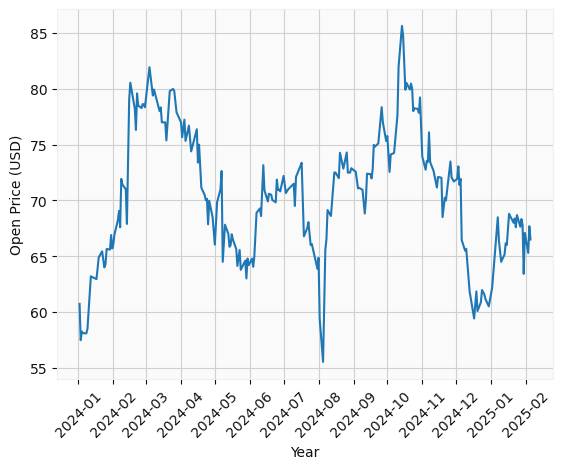

In [27]:
# 複製原始資料，避免影響原 DataFrame
uber_stock1 = uber_stock.copy()
# 將 Date 欄位轉換為 datetime 格式，方便做時間序列分析
uber_stock1["Date"] = pd.to_datetime(uber_stock1["Date"])
# 篩選 2024–2025 年的資料
uber_24_25 = uber_stock1[(uber_stock1["Date"].dt.year >= 2024) & (uber_stock1["Date"].dt.year <= 2025)]
# 建立圖表與座標軸
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
# 繪製開盤價走勢圖
plt.plot(uber_24_25["Date"],uber_24_25["Open"])
# 設定 X 軸：每個月顯示一個刻度
ax.xaxis.set_major_locator(mdates.MonthLocator())
# X 軸日期格式：YYYY-MM
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# 軸標籤
plt.xticks(rotation=45)
plt.xlabel("Year")
plt.ylabel("Open Price (USD)")
# 顯示圖表
plt.show()

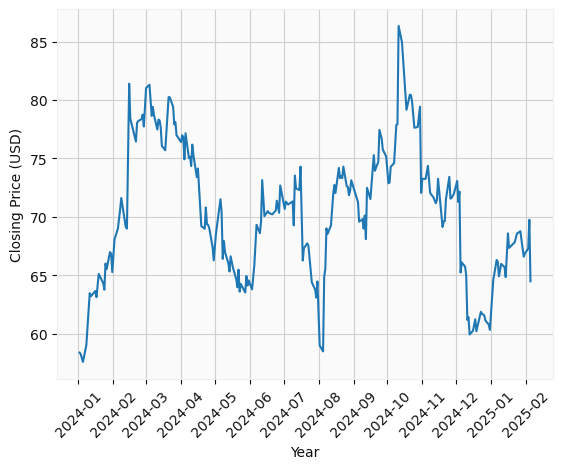

In [28]:
# 複製原始資料，避免影響原 DataFrame
uber_stock1 = uber_stock.copy()
# 將 Date 欄位轉換為 datetime 格式，方便做時間序列分析
uber_stock1["Date"] = pd.to_datetime(uber_stock1["Date"])
# 篩選 2024–2025 年的資料
uber_24_25 = uber_stock1[(uber_stock1["Date"].dt.year >= 2024) & (uber_stock1["Date"].dt.year <= 2025)]
# 建立圖表與座標軸
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
# 繪製收盤價走勢圖
plt.plot(uber_24_25["Date"], uber_24_25["Close"]) 
# 設定 X 軸：每個月顯示一個刻度
ax.xaxis.set_major_locator(mdates.MonthLocator())
# X 軸日期格式：YYYY-MM
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# 軸標籤
plt.xticks(rotation=45)
plt.xlabel("Year")
plt.ylabel("Closing Price (USD)")
# 顯示圖表
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_10932\3193918956.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uber_24_25["MA5"] = uber_24_25["Close"].rolling(5).mean()
C:\Users\user\AppData\Local\Temp\ipykernel_10932\3193918956.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uber_24_25["MA10"] = uber_24_25["Close"].rolling(10).mean()
C:\Users\user\AppData\Local\Temp\ipykernel_10932\3193918956.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

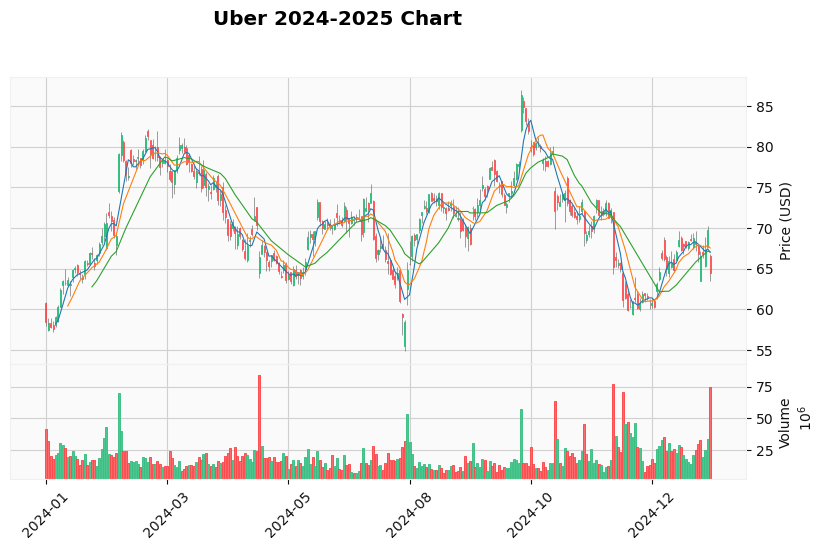

In [30]:
# 複製原始資料，避免影響原 DataFrame
uber_stock2 = uber_stock.copy()
# 將 Date 欄位轉換為 datetime 格式，方便做時間序列分析
uber_stock2["Date"] = pd.to_datetime(uber_stock2["Date"])
# 篩選 2024–2025 年的資料
uber_24_25 = uber_stock2[ (uber_stock2["Date"].dt.year >= 2024) & (uber_stock2["Date"].dt.year <= 2025)]
# 將 Date 變成時間軸， 把這張表變成「時間序列資料」
uber_24_25.set_index("Date", inplace=True)
# 計算均線
uber_24_25["MA5"] = uber_24_25["Close"].rolling(5).mean()
uber_24_25["MA10"] = uber_24_25["Close"].rolling(10).mean()
uber_24_25["MA20"] = uber_24_25["Close"].rolling(20).mean()

#設定要畫哪些移動平均線
mav_list = [5,10,20]

# 繪製圖表
mpf.plot(
    uber_24_25,
    type="candle",
    mav=mav_list,
    volume=True,
    style="yahoo",
    title="Uber 2024-2025 Chart",
    ylabel="Price (USD)",
    ylabel_lower="Volume",
    datetime_format="%Y-%m",
    xrotation=45,
    figratio=(16, 9)
)


IQR 找出的異常值/離群值:
Series([], Name: Close, dtype: float64)


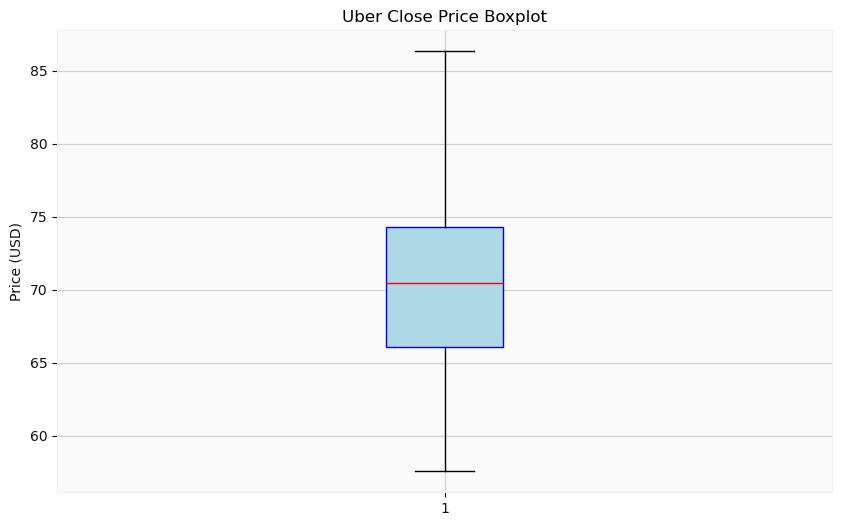

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


R² Score: 0.9886
RMSE: 0.5850


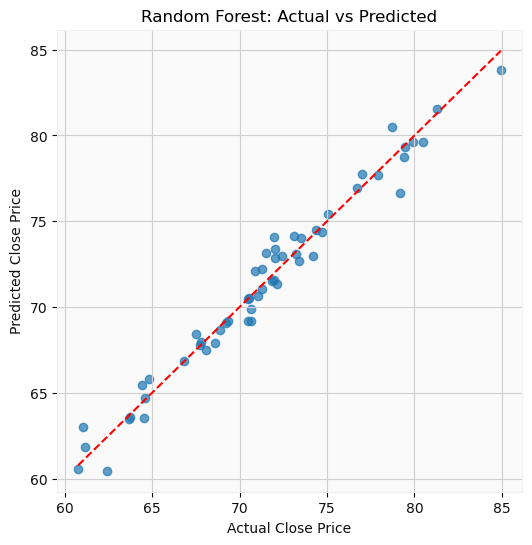

C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RF MAE: 0.7035636012109026


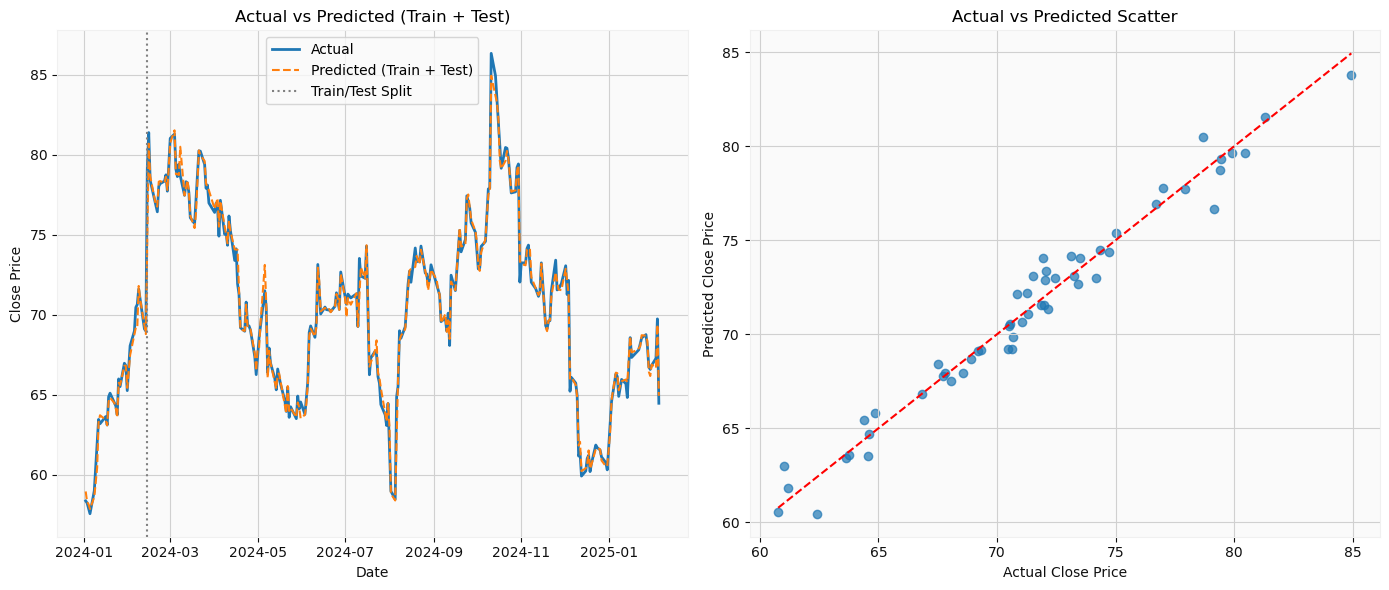

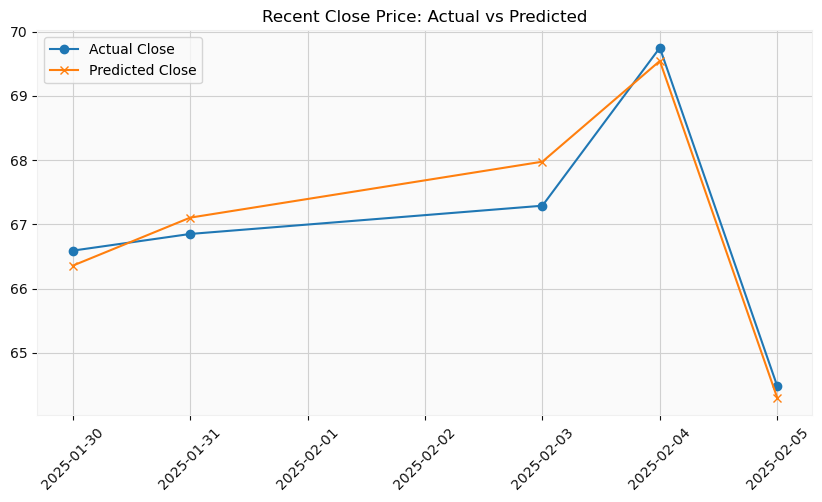

In [33]:
#定義特徵目標
uber_24_25 = uber_24_25.copy()
features = ["Open","Volume","High","Low"]
target = ["Close"]

#刪除NAN欄位
uber_model = uber_24_25.dropna(subset = features + target)

#異常值
#取出收盤價
close = uber_24_25["Close"]
#第 25% 分位點（位置）
Q1 = close.quantile(0.25)
#第 75% 分位點（位置）
Q3 = close.quantile(0.75)
IQR = Q3 - Q1

#上下界-確認哪些資料是正常的、哪些是異常的
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR  

#離群值-不正常、偏離大多數資料的數值
outliers = close[(close < lower) | (close > upper)]
print("IQR 找出的異常值/離群值:")
print(outliers)

# 盒鬚圖-看資料的分布情況、波動大小、以及有沒有異常值
plt.figure(figsize=(10,6))
plt.boxplot(close,
    vert=True,
    patch_artist=True,
    showfliers=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red"),
    flierprops=dict(marker="o", markerfacecolor="red", markersize=8))
plt.title("Uber Close Price Boxplot")
plt.ylabel("Price (USD)")
plt.show()


#資料集切分
x = uber_model[features]
y = uber_model[target]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)
# 建立線性回歸模型物件（尚未訓練）
lr = LinearRegression()
# 訓練線性回歸模型（使用訓練資料）
lr.fit(x_train,y_train)
# 使用訓練資料進行預測（檢查是否過擬合
y_pred = lr.predict(x_test)
y_train_pred = lr.predict(x_train)
# 計算模型評估指標
# R²（決定係數）：衡量模型解釋變異的能力，越接近1越好
r2 = r2_score(y_test, y_pred)
# RMSE（均方根誤差）：預測值與真實值的平均誤差幅度，單位與目標變數相同
rmse = mean_squared_error(y_test, y_pred, squared=False)
# MAE（平均絕對誤差）：平均每筆預測誤差，對離群值較不敏感
mae = mean_absolute_error(y_test,y_pred)
# 輸出評估結果
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# 建立圖表（設定圖表大小為 6x6）
plt.figure(figsize=(6,6))
# 繪製散點圖：x軸為實際值，y軸為預測值
# alpha=0.7 讓點稍微透明，避免重疊看不清
plt.scatter(y_test, y_pred_rf, alpha=0.7)
# 繪製理想預測線（45度對角線）
# 如果模型完全準確，所有點都會落在這條線上
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
# 設定座標軸標籤
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
# 設定圖表標題
plt.title('Random Forest: Actual vs Predicted')
# 顯示圖表
plt.show()

# 建立隨機森林回歸模型
# n_estimators=100：使用100棵決策樹
# random_state=42：固定隨機種子，確保結果可重現
rf = RandomForestRegressor(n_estimators=100,random_state=42)
# 使用訓練資料訓練模型
rf.fit(x_train,y_train)
# 使用測試資料進行預測
y_pred_rf = rf.predict(x_test)
# 計算 MAE（平均絕對誤差）
# 用來衡量預測值與實際值的平均差距
print("RF MAE:", mean_absolute_error(y_test,y_pred_rf))

# 建立一個與原始資料索引相同的空Series，用來存放預測結果
y_pred_all = pd.Series(index=y.index, dtype=float)

# 將訓練資料的預測結果填入（如果有算訓練預測）
y_train_pred_rf = rf.predict(x_train)
y_pred_all.loc[x_train.index] = y_train_pred_rf.ravel()

# 將測試資料的預測結果填入
y_pred_all.loc[x_test.index] = y_pred_rf.ravel()

# 建立圖表（設定圖表大小）
plt.figure(figsize=(14,6))

#左：折線圖
plt.subplot(1,2,1)
# 繪製實際值（收盤價）
plt.plot(y.index, y, label='Actual', linewidth=2)
# 繪製預測值（包含訓練 + 測試）
# 使用虛線區分實際與預測
plt.plot(y_pred_all.index, y_pred_all, label='Predicted (Train + Test)', linestyle='--')
# 標示訓練 / 測試資料分界點
plt.axvline(x=x_test.index[0], color='gray', linestyle=':',label='Train/Test Split')
# 設定座標與標題
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Actual vs Predicted (Train + Test)')
plt.legend()


# 右：散點圖
plt.subplot(1,2,2)
# 繪製散點圖（實際值 vs 預測值）
plt.scatter(y_test, y_pred_rf, alpha=0.7)
# 繪製理想預測線（y = x）
# 點越靠近此線，代表預測越準確
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],'r--')
# 設定座標與標題
plt.xlabel('Actual Close Price')   
plt.ylabel('Predicted Close Price')
plt.title('Actual vs Predicted Scatter')
# 自動調整版面避免重疊
plt.tight_layout()
# 顯示圖表
plt.show()


# 取最近5筆特徵資料（用來模擬近期預測）  
future_X = x.tail(5)
# 取得對應的實際值（用來與預測比較）
future_y_actual = y.tail(5)
# 使用模型進行預測（這裡是 Linear Regression）
future_y_pred = lr.predict(future_X)
# 取得對應日期（作為x軸）
dates = future_X.index
# 建立圖表
plt.figure(figsize=(10,5))
# 繪製實際收盤價
plt.plot(dates, future_y_actual.values.ravel(),
         label='Actual Close',
         marker='o')
# 繪製預測收盤價
plt.plot(dates, future_y_pred.ravel(),
         label='Predicted Close',
         marker='x')
# 設定標題與樣式
plt.title('Recent Close Price: Actual vs Predicted')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

IQR 找出的異常值:
Series([], Name: Close, dtype: float64)


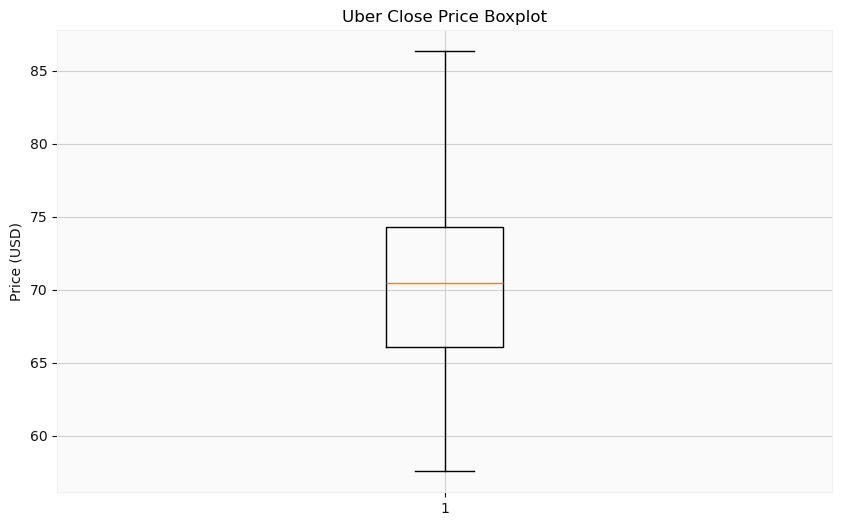

=== Linear Regression ===
R²: 0.9724481472182273
RMSE: 0.6550169782362495
MAE: 0.47670615110065595

=== Random Forest ===
R²: 0.9533215544639742
RMSE: 0.8525804012407063
MAE: 0.6137326506781785


C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


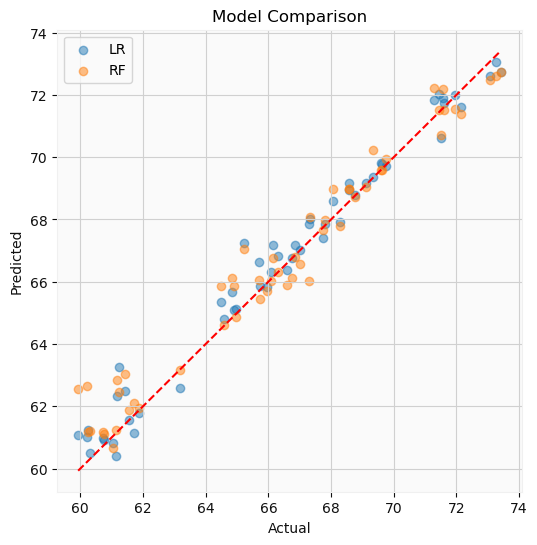

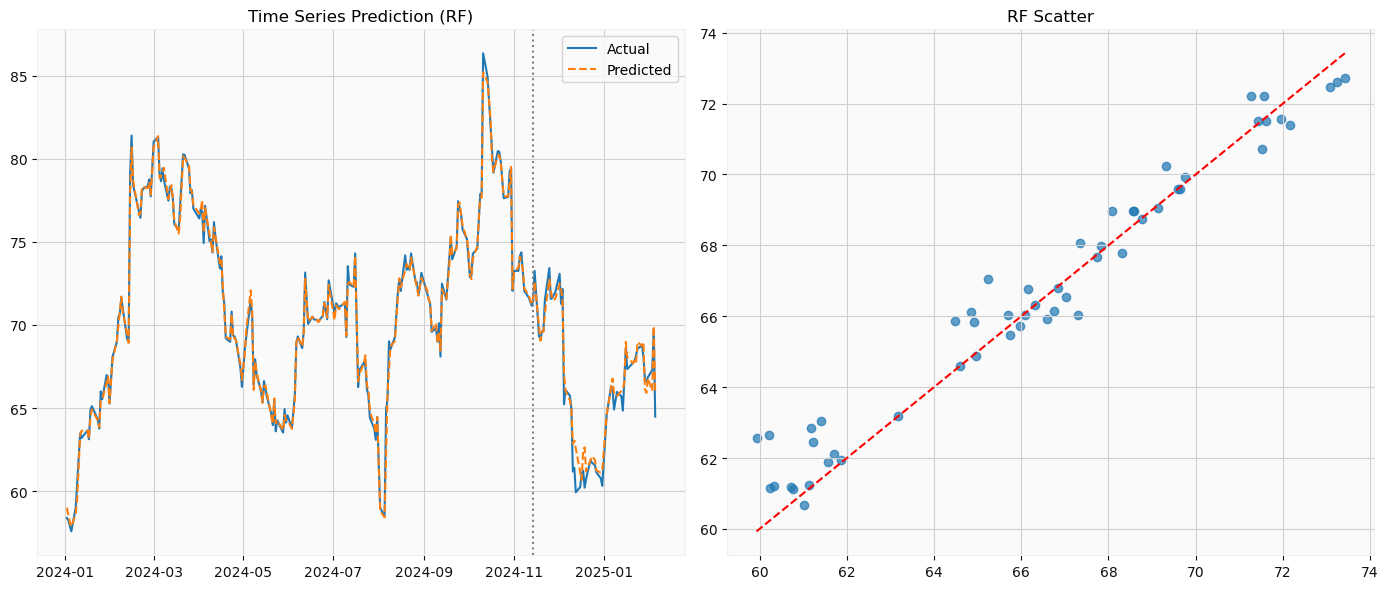

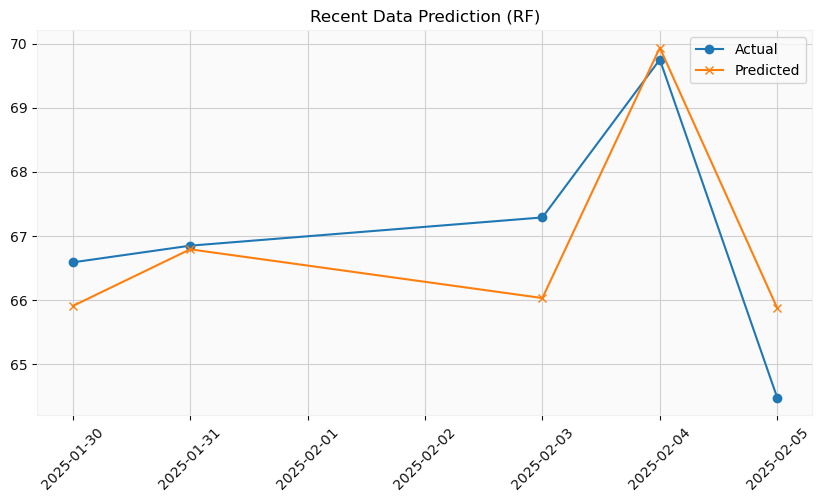

In [34]:
# =========================
# 1️⃣ 資料前處理
# =========================

uber_24_25 = uber_24_25.copy()

# 定義特徵與目標
features = ["Open", "Volume", "High", "Low"]
target = "Close"

# 移除缺失值
uber_model = uber_24_25.dropna(subset=features + [target])

# =========================
# 2️⃣ 異常值檢測（IQR）
# =========================

close = uber_model["Close"]

Q1 = close.quantile(0.25)
Q3 = close.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = close[(close < lower) | (close > upper)]
print("IQR 找出的異常值:")
print(outliers)

# 移除異常值
uber_model = uber_model[(uber_model["Close"] >= lower) & (uber_model["Close"] <= upper)]

# 盒鬚圖
plt.figure(figsize=(10,6))
plt.boxplot(close, vert=True, showfliers=True)
plt.title("Uber Close Price Boxplot")
plt.ylabel("Price (USD)")
plt.show()


# =========================
# 3️⃣ 建立資料集（時間序列切分）
# =========================

x = uber_model[features]
y = uber_model[target]
#取 80% 當訓練資料
split = int(len(x) * 0.8)

x_train = x.iloc[:split]
x_test = x.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]


# =========================
# 4️⃣ 建立模型（LR + RF）
# =========================

# Linear Regression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

# Random Forest（主模型）
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)


# =========================
# 5️⃣ 模型評估
# =========================

print("=== Linear Regression ===")
print("R²:", r2_score(y_test, y_pred_lr))
print("RMSE:", mean_squared_error(y_test, y_pred_lr, squared=False))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

print("\n=== Random Forest ===")
print("R²:", r2_score(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf, squared=False))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))


# =========================
# 6️⃣ Scatter
# =========================

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr, alpha=0.5, label="LR")
plt.scatter(y_test, y_pred_rf, alpha=0.5, label="RF")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Comparison")
plt.legend()
plt.show()


# =========================
# 7️⃣ 時間序列重建（RF）
# =========================

y_pred_all = pd.Series(index=y.index, dtype=float)

y_train_pred_rf = rf.predict(x_train)

y_pred_all.loc[x_train.index] = y_train_pred_rf
y_pred_all.loc[x_test.index] = y_pred_rf

plt.figure(figsize=(14,6))

# 左圖：時間序列
plt.subplot(1,2,1)
plt.plot(y.index, y, label="Actual")
plt.plot(y_pred_all.index, y_pred_all, '--', label="Predicted")
plt.axvline(x=x_test.index[0], color='gray', linestyle=':')
plt.title("Time Series Prediction (RF)")
plt.legend()

# 右圖：Scatter
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("RF Scatter")

plt.tight_layout()
plt.show()


# =========================
# 8️⃣ 最近資料預測（RF）
# =========================

future_X = x.tail(5)
future_y_actual = y.tail(5)
future_y_pred = rf.predict(future_X)

dates = future_X.index

plt.figure(figsize=(10,5))

plt.plot(dates, future_y_actual,
         label="Actual", marker='o')

plt.plot(dates, future_y_pred,
         label="Predicted", marker='x')

plt.title("Recent Data Prediction (RF)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()